---
**PRÁCTICA N°1**  
**Nombre:** Roberto Roly Copa Mamani  
**Materia:** Machine Learning - INF 672

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

np.random.seed(42)

---
**Ejercicio 1**

In [2]:
rng = np.random.default_rng(42)

tamanos = [100, 1000, 100000]
resultados = []

for N in tamanos:
    tiradas = rng.integers(1, 7, size=N)
    cantidad_pares = (tiradas % 2 == 0).sum()
    probabilidad = cantidad_pares / N
    error = abs(probabilidad - 0.5)

    resultados.append({
        "N": N,
        "Pares": cantidad_pares,
        "Probabilidad estimada": probabilidad,
        "Valor teórico": 0.5,
        "Error absoluto": error
    })

tabla_probabilidades = pd.DataFrame(resultados)
tabla_probabilidades

,N,Pares,Probabilidad estimada,Valor teórico,Error absoluto
0,100,38,0.38000,0.5,0.12000
1,1000,489,0.48900,0.5,0.01100
2,100000,49979,0.49979,0.5,0.00021


La estimación que más se acercó al valor teórico fue la obtenida con 100.000 lanzamientos. Esto ocurre porque, al aumentar la cantidad de experimentos, la frecuencia relativa tiende a estabilizarse alrededor de la probabilidad real

Cuando tenemos pocos datos, el azar tiene una influencia mayor y la estimación puede alejarse bastante del valor esperado

---
**Ejercicio 2**

In [3]:
iris = load_iris()

petal_length = iris.data[:, 2]

media = np.mean(petal_length)
mediana = np.median(petal_length)
desviacion = np.std(petal_length)
minimo = np.min(petal_length)
maximo = np.max(petal_length)

print(f"Media: {media:.3f}")
print(f"Mediana: {mediana:.3f}")
print(f"Desviación estándar: {desviacion:.3f}")
print(f"Mínimo: {minimo:.3f}")
print(f"Máximo: {maximo:.3f}")

Media: 3.758
Mediana: 4.350
Desviación estándar: 1.759
Mínimo: 1.000
Máximo: 6.900


1. **Media = 3.758 cm:** indica que, considerando todas las flores, el largo promedio de los pétalos es aproximadamente 3.76 cm.

2. **Mediana = 4.350 cm:** significa que la mitad de las flores posee pétalos con una longitud menor o igual a 4.35 cm y la otra mitad mayor o igual.

3. **Desviación estándar ≈ 1.759 cm:** indica que existe una variación considerable en el largo de los pétalos respecto a la media, lo cual tiene sentido porque Iris contiene tres especies diferentes.

4. **Mínimo = 1.000 cm:** corresponde al pétalo más corto encontrado en el conjunto de datos.

5. **Máximo = 6.900 cm:** corresponde al pétalo más largo registrado.

La media y la mediana no están demasiado alejadas, aunque la mediana es algo mayor. Esto sugiere que la distribución no es completamente simétrica y que existen grupos diferenciados dentro de los datos, principalmente debido a las distintas especies de Iris.

---
**Ejercicio 3**

In [4]:
iris = load_iris()

a = iris.data[0]
b = iris.data[1]
c = iris.data[50]

print("Flor 0:", iris.target_names[iris.target[0]])
print("Flor 1:", iris.target_names[iris.target[1]])
print("Flor 50:", iris.target_names[iris.target[50]])

Flor 0: setosa
Flor 1: setosa
Flor 50: versicolor


In [5]:
def distancia_manual(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def distancia_numpy(a, b):
    return np.linalg.norm(a - b)

pares = [
    ("Flor 0 - Flor 1", a, b),
    ("Flor 0 - Flor 50", a, c),
    ("Flor 1 - Flor 50", b, c)
]

resultados = []

for nombre, flor1, flor2 in pares:
    resultados.append({
        "Par": nombre,
        "Método manual": distancia_manual(flor1, flor2),
        "np.linalg.norm": distancia_numpy(flor1, flor2)
    })

pd.DataFrame(resultados)

,Par,Método manual,np.linalg.norm
0,Flor 0 - Flor 1,0.538516,0.538516
1,Flor 0 - Flor 50,4.003748,4.003748
2,Flor 1 - Flor 50,4.096340,4.096340


Las flores de índices **0 y 1**, que pertenecen a la misma especie, presentan una distancia mucho menor que las distancias obtenidas al compararlas con la flor de índice 50. Además, los resultados obtenidos con la fórmula manual y con `np.linalg.norm()` son iguales, lo que confirma que ambos procedimientos calculan la misma distancia euclidiana.

Tiene sentido que las flores de una misma especie estén numéricamente más cerca porque comparten características físicas similares, como el largo y ancho de sus sépalos y pétalos. Por ello, la distancia euclidiana puede utilizarse como una medida sencilla de similitud.

---
**Ejercicio 4**

In [6]:
df = pd.DataFrame({
    "ingreso": [3200, 4100, np.nan, 2800, 5000, np.nan, 3600, 4800],
    "ciudad": ["Potosí", "Sucre", "Potosí", "La Paz", np.nan, "Sucre", "Potosí", "La Paz"],
    "edad": [28, 35, 41, 23, 52, 30, 45, 38]
})

df

,ingreso,ciudad,edad
0,3200.0,Potosí,28
1,4100.0,Sucre,35
2,NaN,Potosí,41
3,2800.0,La Paz,23
4,5000.0,NaN,52
5,NaN,Sucre,30
6,3600.0,Potosí,45
7,4800.0,La Paz,38


In [7]:
faltantes = df.isna().sum()

print("Valores faltantes por columna:")
print(faltantes)

Valores faltantes por columna:
ingreso    2
ciudad     1
edad       0
dtype: int64


In [8]:
mediana_ingreso = df["ingreso"].median()

print("Mediana de ingreso:", mediana_ingreso)

df["ingreso"] = df["ingreso"].fillna(mediana_ingreso)

df

Mediana de ingreso: 3850.0


,ingreso,ciudad,edad
0,3200.0,Potosí,28
1,4100.0,Sucre,35
2,3850.0,Potosí,41
3,2800.0,La Paz,23
4,5000.0,NaN,52
5,3850.0,Sucre,30
6,3600.0,Potosí,45
7,4800.0,La Paz,38


**¿Por qué utilizar la mediana?**

Para reemplazar los ingresos faltantes se utiliza la **mediana** porque es menos sensible a valores extremadamente altos o bajos. Por ejemplo, si una persona tuviera un ingreso mucho mayor que las demás, podría elevar considerablemente la media. La mediana, en cambio, representa el valor central y se mantiene más estable frente a valores extremos.

In [9]:
df_final = pd.get_dummies(df, columns=["ciudad"], dtype=int)

df_final

,ingreso,edad,ciudad_La Paz,ciudad_Potosí,ciudad_Sucre
0,3200.0,28,0,1,0
1,4100.0,35,0,0,1
2,3850.0,41,0,1,0
3,2800.0,23,1,0,0
4,5000.0,52,0,0,0
5,3850.0,30,0,0,1
6,3600.0,45,0,1,0
7,4800.0,38,1,0,0


In [10]:
print("Valores faltantes en la tabla final:")
print(df_final.isna().sum())

Valores faltantes en la tabla final:
ingreso          0
edad             0
ciudad_La Paz    0
ciudad_Potosí    0
ciudad_Sucre     0
dtype: int64


La variable `ciudad`, que originalmente contenía texto, se transformó en varias columnas numéricas de ceros y unos. Por ejemplo:

- `ciudad_La Paz = 1` indica que el registro pertenece a La Paz
- `ciudad_Potosí = 1` indica que pertenece a Potosí
- `ciudad_Sucre = 1` indica que pertenece a Sucre

Cuando una columna contiene 0 significa que esa persona no pertenece a esa ciudad. De esta manera, los datos categóricos quedan representados numéricamente y pueden ser utilizados posteriormente por algoritmos de Machine Learning.

---
**Ejercicio 5**

In [11]:
iris = load_iris()

largo = iris.data[:, 2]
ancho = iris.data[:, 3]

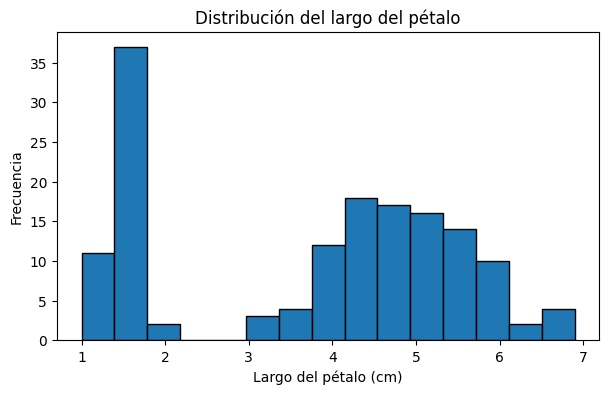

In [12]:
plt.figure(figsize=(7, 4))
plt.hist(largo, bins=15, edgecolor="black")

plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Frecuencia")
plt.title("Distribución del largo del pétalo")

plt.show()

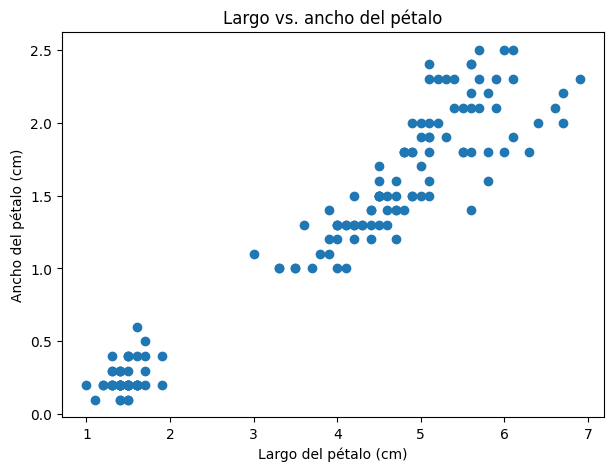

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(largo, ancho)

plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.title("Largo vs. ancho del pétalo")

plt.show()

In [14]:
correlacion = np.corrcoef(largo, ancho)[0, 1]

print(f"Correlación de Pearson: {correlacion:.4f}")

Correlación de Pearson: 0.9629


La correlación obtenida es aproximadamente 0.9629, por lo que existe una relación positiva muy fuerte entre el largo y el ancho del pétalo. Esto coincide con lo observado en el gráfico de dispersión, a medida que aumenta el largo del pétalo, generalmente también aumenta su ancho.

Un coeficiente cercano a:

- **+1** indica una relación positiva muy fuerte
- **0** indica que prácticamente no existe una relación lineal
- **−1** indica una relación negativa muy fuerte, es decir, mientras una variable aumenta, la otra disminuye

En este caso, el valor cercano a +1 confirma lo observado visualmente.

---
**Ejercicio 6**

In [15]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()

df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df = df.drop(columns=["target"])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
caracteristicas = [col for col in df.columns if col != "species"]

filas = []

for especie, grupo in df.groupby("species"):
    for caracteristica in caracteristicas:
        datos = grupo[caracteristica]

        filas.append({
            "Especie": especie,
            "Característica": caracteristica,
            "Media": datos.mean(),
            "Mediana": datos.median(),
            "Desviación estándar": datos.std(),
            "Rango": datos.max() - datos.min(),
            "Q1": datos.quantile(0.25),
            "Q2": datos.quantile(0.50),
            "Q3": datos.quantile(0.75)
        })

tabla_estadistica = pd.DataFrame(filas)

tabla_estadistica.round(3)

,Especie,Característica,Media,Mediana,Desviación estándar,Rango,Q1,Q2,Q3
0,setosa,sepal length (cm),5.006,5.00,0.352,1.5,4.800,5.00,5.200
1,setosa,sepal width (cm),3.428,3.40,0.379,2.1,3.200,3.40,3.675
2,setosa,petal length (cm),1.462,1.50,0.174,0.9,1.400,1.50,1.575
3,setosa,petal width (cm),0.246,0.20,0.105,0.5,0.200,0.20,0.300
4,versicolor,sepal length (cm),5.936,5.90,0.516,2.1,5.600,5.90,6.300
5,versicolor,sepal width (cm),2.770,2.80,0.314,1.4,2.525,2.80,3.000
6,versicolor,petal length (cm),4.260,4.35,0.470,2.1,4.000,4.35,4.600
7,versicolor,petal width (cm),1.326,1.30,0.198,0.8,1.200,1.30,1.500
8,virginica,sepal length (cm),6.588,6.50,0.636,3.0,6.225,6.50,6.900
9,virginica,sepal width (cm),2.974,3.00,0.322,1.6,2.800,3.00,3.175


In [17]:
df.groupby("species")[caracteristicas].mean().round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Las características relacionadas con los pétalos son las que permiten distinguir mejor a las tres especies, en particular, el **largo del pétalo (`petal length`)** presenta medias claramente diferentes entre Setosa, Versicolor y Virginica, mientras que la dispersión dentro de cada especie es relativamente pequeña.

Setosa posee pétalos considerablemente más cortos, Versicolor presenta valores intermedios y Virginica los valores más altos.

Por ello, el largo del pétalo resulta una de las características más útiles para separar las especies. El ancho del pétalo también presenta un comportamiento muy similar y proporciona una separación bastante clara.

---
**Ejercicio 7**

In [18]:
def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


def producto_punto(a, b):
    return np.sum(a * b)


def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [19]:
iris = load_iris()

indices = [0, 1, 50, 100]

for i in indices:
    print(
        f"Índice {i}:",
        iris.target_names[iris.target[i]],
        iris.data[i]
    )

Índice 0: setosa [5.1 3.5 1.4 0.2]
Índice 1: setosa [4.9 3.  1.4 0.2]
Índice 50: versicolor [7.  3.2 4.7 1.4]
Índice 100: virginica [6.3 3.3 6.  2.5]


In [20]:
pares = [
    (0, 1),
    (0, 50),
    (0, 100),
    (50, 100)
]

resultados = []

for i, j in pares:
    a = iris.data[i]
    b = iris.data[j]

    resultados.append({
        "Par": f"{i} - {j}",
        "Especie A": iris.target_names[iris.target[i]],
        "Especie B": iris.target_names[iris.target[j]],
        "Distancia euclidiana": distancia_euclidiana(a, b),
        "Producto punto": producto_punto(a, b),
        "Similitud coseno": similitud_coseno(a, b)
    })

tabla_comparacion = pd.DataFrame(resultados)

tabla_comparacion.round(4)

,Par,Especie A,Especie B,Distancia euclidiana,Producto punto,Similitud coseno
0,0 - 1,setosa,setosa,0.5385,37.49,0.9986
1,0 - 50,setosa,versicolor,4.0037,53.76,0.9284
2,0 - 100,setosa,virginica,5.2849,52.58,0.8601
3,50 - 100,versicolor,virginica,1.8439,86.36,0.9821


La distancia euclidiana y la similitud coseno no siempre expresan la semejanza exactamente de la misma manera.  
La **distancia euclidiana** observa la separación absoluta entre los puntos, mientras menor sea la distancia, más parecidas son las flores.  
La **similitud coseno**, en cambio, compara principalmente la dirección o el ángulo entre los vectores. Un valor cercano a 1 significa que ambos vectores tienen una orientación muy similar.

En los resultados, las flores 0 y 1, que pertenecen a Setosa, presentan una distancia muy pequeña y una similitud coseno cercana a 1.

Sin embargo, puede ocurrir que dos flores tengan una similitud coseno elevada y al mismo tiempo estén separadas por una distancia euclidiana mayor. Esto sucede porque el coseno se fija principalmente en el ángulo, mientras que la distancia euclidiana también toma en cuenta la magnitud de los valores.

---
**Ejercicio 8**

In [21]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()

df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df = df.drop(columns=["target"])

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


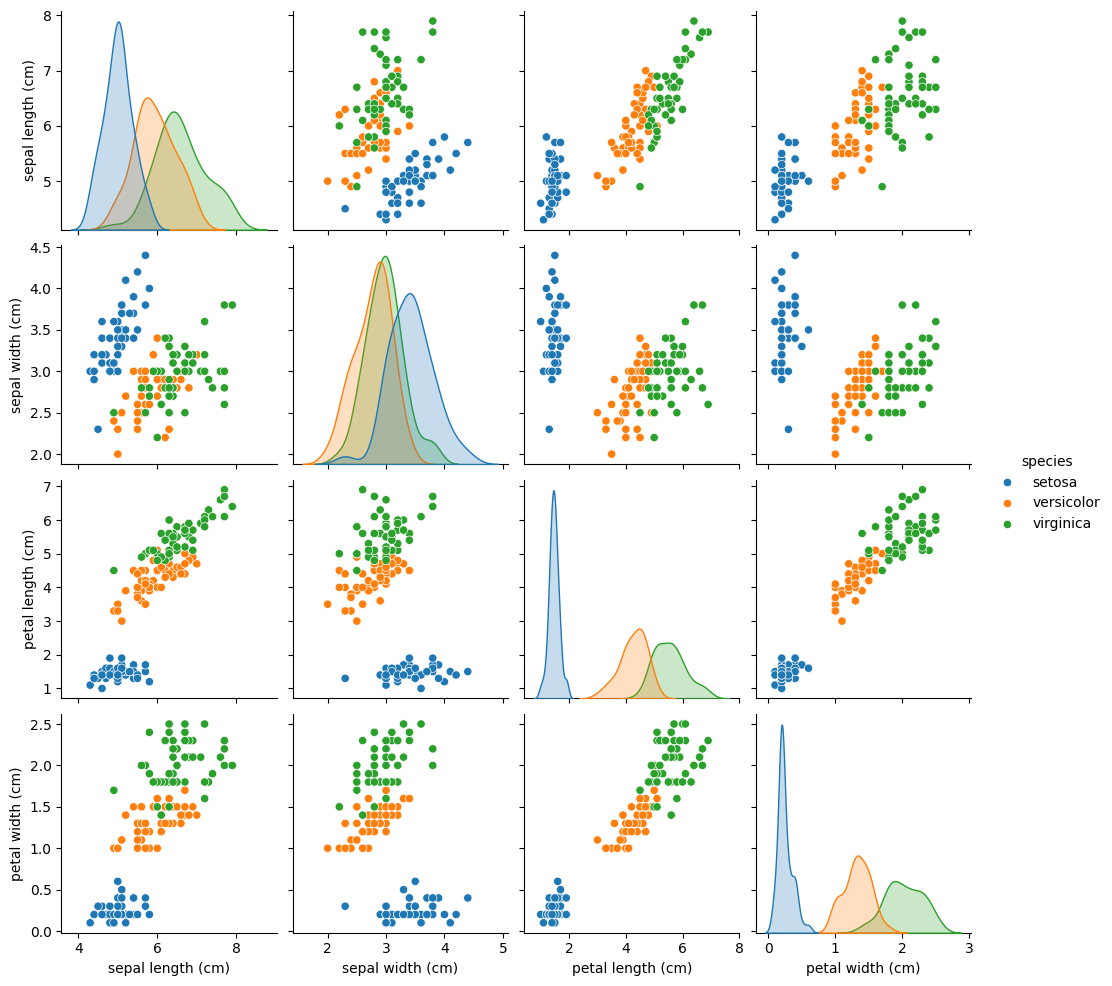

In [22]:
sns.pairplot(df, hue="species")

plt.show()

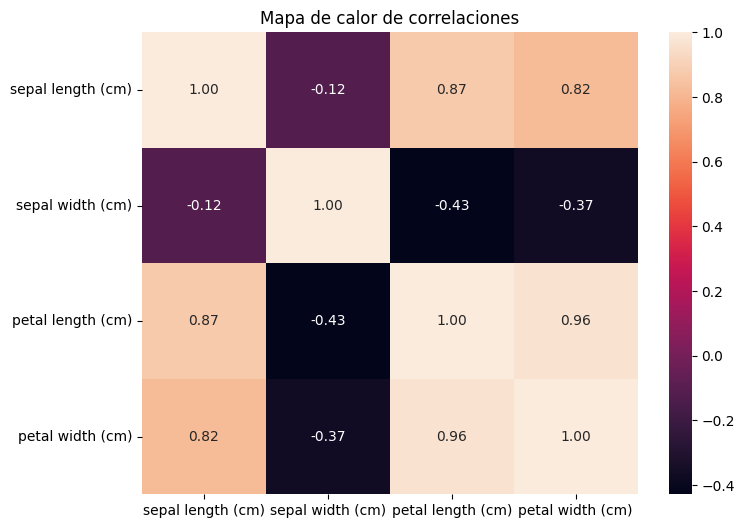

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f"
)

plt.title("Mapa de calor de correlaciones")

plt.show()

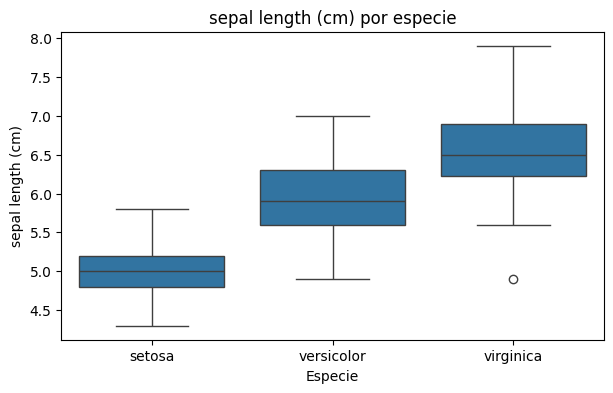

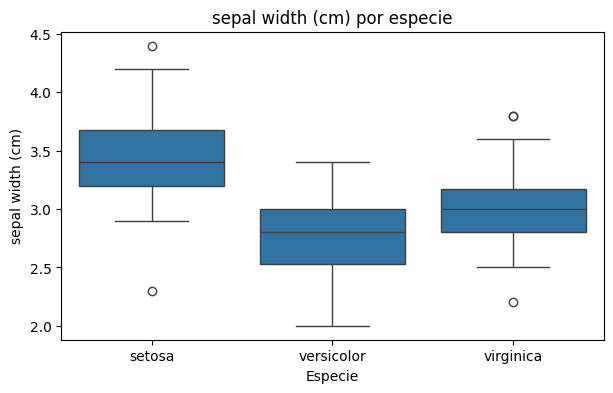

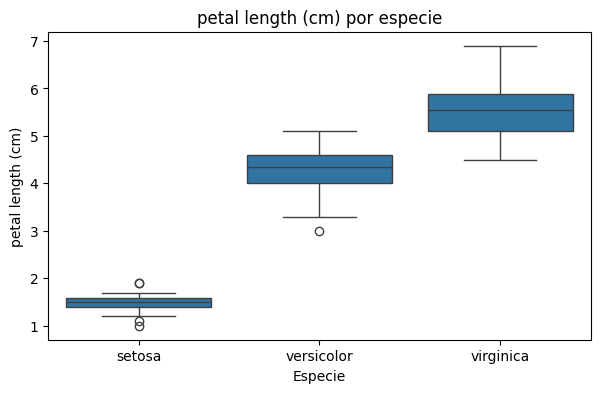

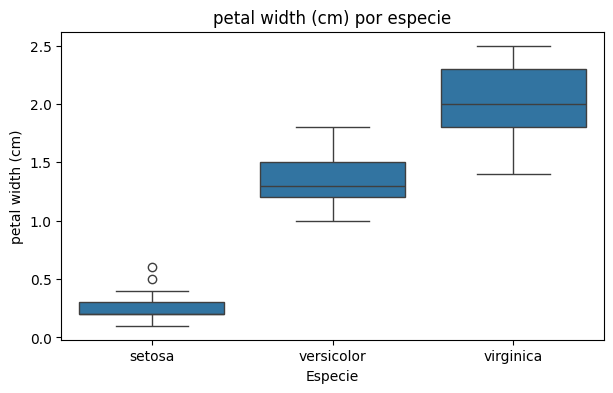

In [24]:
for columna in df.columns[:-1]:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="species",
        y=columna
    )

    plt.title(f"{columna} por especie")
    plt.xlabel("Especie")
    plt.ylabel(columna)

    plt.show()

El `pairplot` permite observar que las características relacionadas con los pétalos ofrecen la separación más clara entre las especies.  
El par **petal length – petal width** permite distinguir muy bien a Setosa de las demás especies y también muestra una separación considerable entre Versicolor y Virginica.  
En cambio, características como **sepal length – sepal width** presentan bastante solapamiento, principalmente entre Versicolor y Virginica, por lo que resultaría más difícil separarlas mediante una línea sencilla.

El mapa de calor también muestra una correlación positiva muy alta entre el largo y el ancho del pétalo, lo que confirma que ambas características tienden a aumentar juntas.

Los boxplots permiten comprobar que Setosa posee pétalos mucho más pequeños, Versicolor tiene valores intermedios y Virginica generalmente presenta los valores más altos.

---
**Ejercicio 9**

In [25]:
def f(x):
    return (x - 3) ** 2 + 2


def derivada(x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

In [26]:
def descenso_gradiente(x_inicial, tasa, pasos=30):

    x = x_inicial
    trayectoria = [x]

    for _ in range(pasos):

        gradiente = derivada(x)

        x = x - tasa * gradiente

        trayectoria.append(x)

    return np.array(trayectoria)

In [27]:
tasas = [0.01, 0.1, 1.1]

trayectorias = {}

for tasa in tasas:

    trayectoria = descenso_gradiente(
        x_inicial=10,
        tasa=tasa,
        pasos=30
    )

    trayectorias[tasa] = trayectoria

    print(f"Tasa {tasa}")
    print(f"x final = {trayectoria[-1]}")
    print()

Tasa 0.01
x final = 6.818390235763019

Tasa 0.1
x final = 3.008665580274119

Tasa 1.1
x final = 1664.6341428448138



In [28]:
tabla_trayectorias = pd.DataFrame({
    f"Tasa {tasa}": trayectoria
    for tasa, trayectoria in trayectorias.items()
})

tabla_trayectorias

,Tasa 0.01,Tasa 0.1,Tasa 1.1
0,10.000000,10.000000,10.000000
1,9.860000,8.600000,-5.400000
2,9.722800,7.480000,13.080000
3,9.588344,6.584000,-9.096000
4,9.456577,5.867200,17.515200
5,9.327446,5.293760,-14.418240
6,9.200897,4.835008,23.901888
7,9.076879,4.468006,-22.082266
8,8.955341,4.174405,33.098719
9,8.836234,3.939524,-33.118462


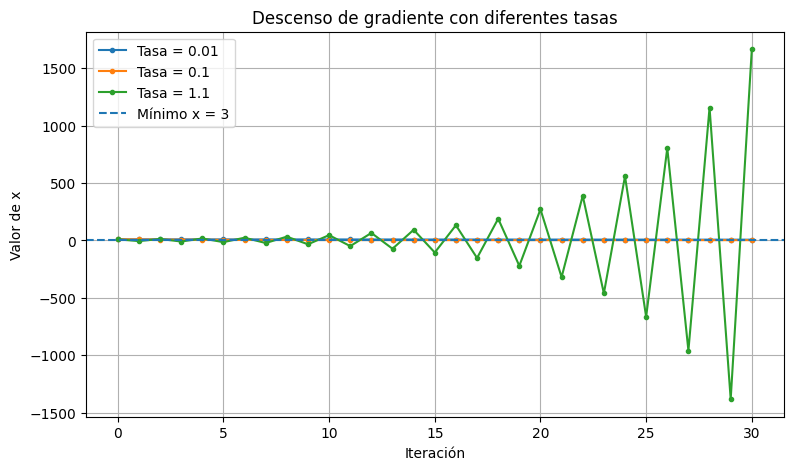

In [29]:
plt.figure(figsize=(9, 5))

for tasa, trayectoria in trayectorias.items():

    plt.plot(
        range(len(trayectoria)),
        trayectoria,
        marker="o",
        markersize=3,
        label=f"Tasa = {tasa}"
    )

plt.axhline(
    y=3,
    linestyle="--",
    label="Mínimo x = 3"
)

plt.xlabel("Iteración")
plt.ylabel("Valor de x")
plt.title("Descenso de gradiente con diferentes tasas")
plt.legend()
plt.grid()

plt.show()

Las tres tasas producen comportamientos diferentes. Con una tasa de **0.01**, el algoritmo avanza en la dirección correcta, pero lo hace lentamente, después de pocas iteraciones todavía puede encontrarse relativamente lejos del mínimo.  Con una tasa de **0.1**, el algoritmo converge rápidamente hacia `x = 3`, por lo que presenta un comportamiento estable y eficiente. Con una tasa de **1.1**, los pasos son demasiado grandes, el algoritmo sobrepasa repetidamente el mínimo y las oscilaciones aumentan, por lo que termina alejándose en lugar de converger.

Esto demuestra que elegir la tasa de aprendizaje es delicado: una tasa demasiado pequeña hace que el aprendizaje sea lento, mientras que una tasa demasiado grande puede provocar oscilaciones o incluso divergencia.

---
**Ejercicio 10**

In [30]:
from itertools import product

espacio_muestral = list(
    product(range(1, 7), repeat=3)
)

favorables = [
    resultado
    for resultado in espacio_muestral
    if sum(resultado) == 10
]

total_casos = len(espacio_muestral)
casos_favorables = len(favorables)

probabilidad_exacta = casos_favorables / total_casos

print("Total de casos:", total_casos)
print("Casos favorables:", casos_favorables)
print("Probabilidad exacta:", probabilidad_exacta)

Total de casos: 216
Casos favorables: 27
Probabilidad exacta: 0.125


In [31]:
rng = np.random.default_rng(42)

N = 100000

tiradas = rng.integers(
    1,
    7,
    size=(N, 3)
)

sumas = tiradas.sum(axis=1)

estimacion = (sumas == 10).mean()

print("Probabilidad exacta:", probabilidad_exacta)
print("Probabilidad estimada:", estimacion)
print("Error absoluto:", abs(estimacion - probabilidad_exacta))

Probabilidad exacta: 0.125
Probabilidad estimada: 0.12504
Error absoluto: 4.000000000001225e-05


In [32]:
tamanos = [10, 100, 10000, 100000]

resultados = []

for N in tamanos:

    rng = np.random.default_rng(42)

    tiradas = rng.integers(
        1,
        7,
        size=(N, 3)
    )

    sumas = tiradas.sum(axis=1)

    estimacion = (sumas == 10).mean()

    error = abs(
        estimacion - probabilidad_exacta
    )

    resultados.append({
        "N": N,
        "Estimación": estimacion,
        "Valor exacto": probabilidad_exacta,
        "Error absoluto": error
    })

tabla_error = pd.DataFrame(resultados)

tabla_error

,N,Estimación,Valor exacto,Error absoluto
0,10,0.20000,0.125,0.07500
1,100,0.15000,0.125,0.02500
2,10000,0.12170,0.125,0.00330
3,100000,0.12504,0.125,0.00004


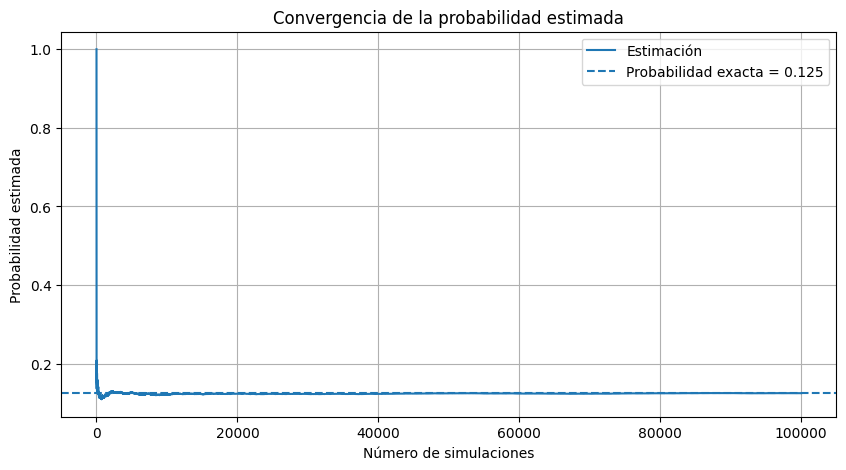

In [33]:
rng = np.random.default_rng(42)

N = 100000

tiradas = rng.integers(
    1,
    7,
    size=(N, 3)
)

eventos = (
    tiradas.sum(axis=1) == 10
).astype(int)

estimacion_acumulada = (
    np.cumsum(eventos) /
    np.arange(1, N + 1)
)

plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, N + 1),
    estimacion_acumulada,
    label="Estimación"
)

plt.axhline(
    probabilidad_exacta,
    linestyle="--",
    label="Probabilidad exacta = 0.125"
)

plt.xlabel("Número de simulaciones")
plt.ylabel("Probabilidad estimada")
plt.title("Convergencia de la probabilidad estimada")
plt.legend()
plt.grid()

plt.show()

Mediante el conteo exacto se obtuvo una probabilidad de **0.125**, equivalente al 12.5 %, para que la suma de tres dados sea igual a 10.
La simulación muestra que, con pocas tiradas, la estimación puede estar bastante alejada de ese valor debido al efecto del azar. A medida que aumenta el número de simulaciones, la frecuencia relativa comienza a estabilizarse y se aproxima cada vez más a 0.125. A partir de varios miles de simulaciones la estimación ya presenta un comportamiento mucho más estable. Con 10.000 y especialmente con 100.000 observaciones, el error suele ser pequeño.

Por tanto, se observa que **al aumentar el número de experimentos, generalmente disminuye el error de estimación**, aunque pueden existir pequeñas fluctuaciones aleatorias